# MODEL 3 — AI-GENERATED IMAGE EVIDENCE ANALYSIS

##

---

### Module Objective

Analyze digital images to determine whether they are:

- **REAL**
- **AI-GENERATED / FAKE**

### Dataset

**ProGAN + CIFAKE**

- Total Images: **28,000**
- REAL: **14,000**
- FAKE: **14,000**

### AI Model

**ResNet-18**

- Input: **224 × 224 RGB Image**
- Output: **REAL / FAKE**
- Classes: **2**

### Module Purpose

This module provides an **AI-based forensic analysis capability** for the
AI Digital Evidence Intelligence Platform.

It evaluates image authenticity and identifies potential
AI-generated or manipulated visual evidence.

### Evaluation

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- ROC-AUC

### Generalization Analysis

The model is trained using images from **ProGAN and CIFAKE** and is
additionally evaluated on a separate CIFAKE test set to measure
cross-dataset generalization.

---


#  1: INSTALL REQUIRED LIBRARIES


This cell installs the essential libraries required for the AI image forensics module.
PyTorch and Torchvision are used for deep learning and image processing.
Scikit-learn, Pandas, and Matplotlib support evaluation, data analysis, and visualization.
Pillow handles image loading, while tqdm provides progress tracking during processing.

In [ ]:
!pip install -q kaggle torch torchvision scikit-learn pandas matplotlib pillow tqdm



# 2: KAGGLE API SETUP

This cell configures the Kaggle API environment in Google Colab.
The kaggle.json file is uploaded to provide secure authentication.
The credentials are stored with restricted permissions.
This enables direct downloading of the required forensic image datasets from Kaggle.

In [ ]:

from google.colab import files
import os
import json

print("=" * 70)
print("KAGGLE API SETUP")
print("=" * 70)

print("\nUpload your kaggle.json file when prompted.")

uploaded = files.upload()

# Check that kaggle.json was uploaded
if "kaggle.json" not in uploaded:
    raise FileNotFoundError(
        "kaggle.json was not uploaded. Please run this cell again."
    )

# Configure Kaggle API
os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("\n✅ Kaggle API configured successfully.")
print("Ready to download the Model 3 dataset.")

KAGGLE API SETUP

Upload your kaggle.json file when prompted.


Saving kaggle.json to kaggle.json

✅ Kaggle API configured successfully.
Ready to download the Model 3 dataset.



# 3: VERIFY KAGGLE DATASET


This cell verifies that the required dataset is available through the Kaggle API.
It searches Kaggle for the ArtiFact: Real and Fake Image Dataset.
The displayed results confirm the dataset reference and its availability.
This ensures the correct dataset is identified before downloading it.

In [ ]:
!kaggle datasets list -s "artifact dataset"

ref                                                          title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
awsaf49/artifact-dataset                                     ArtiFact: Real and Fake Image Dataset           31580400175  2023-02-23 09:40:56.670000          20084         97  0.7647059        
jesucristo/super-resolution-benchmarks                       Super Resolution Benchmarks                       967921789  2022-10-03 01:39:46.627000           3754         62  0.9375           
abhinavrama22/archaeomind-images                             archaeomind_images                                200594668  2026-01-26 05:57:20.463000            124         10  0.6875           
abhinavwalia95/entity-annotate

# 4: DOWNLOAD ARTIFACT DATASET



This cell downloads the selected ArtiFact dataset directly from Kaggle.
The dataset is saved into the specified Colab directory for further processing.
The download progress is displayed to confirm successful data transfer.
This prepares the forensic image dataset for inspection and model training.

In [ ]:
import os

DATASET = "awsaf49/artifact-dataset"
DOWNLOAD_DIR = "/content/artifact_dataset"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("=" * 70)
print("DOWNLOADING ARTIFACT DATASET")
print("=" * 70)
print("Dataset :", DATASET)
print("Target  :", DOWNLOAD_DIR)
print()

!kaggle datasets download -d awsaf49/artifact-dataset -p /content/artifact_dataset

print("\n" + "=" * 70)
print("DOWNLOAD COMMAND COMPLETED")
print("=" * 70)

DOWNLOADING ARTIFACT DATASET
Dataset : awsaf49/artifact-dataset
Target  : /content/artifact_dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/artifact-dataset
License(s): other
100% 29.4G/29.4G [12:33<00:00, 41.9MB/s]


DOWNLOAD COMMAND COMPLETED



# 5: INSPECT DATASET ARCHIVE


This cell inspects the downloaded ArtiFact dataset ZIP archive before extraction.
It identifies the ZIP file, checks its size, and reads the archive structure.
The total number of files and sample file paths are displayed for verification.
This helps confirm the dataset contents and organization before further processing.

In [ ]:
import os
import zipfile

DOWNLOAD_DIR = "/content/artifact_dataset"

zip_files = [
    f for f in os.listdir(DOWNLOAD_DIR)
    if f.lower().endswith(".zip")
]

print("=" * 70)
print("ARTIFACT DATASET ARCHIVE")
print("=" * 70)

if not zip_files:
    raise FileNotFoundError("No ZIP file found in the download directory.")

zip_path = os.path.join(DOWNLOAD_DIR, zip_files[0])

print("ZIP file :", zip_path)
print("Size GB  :", round(os.path.getsize(zip_path) / (1024**3), 2))

print("\nReading archive structure...")

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Total files in archive:", len(files))

print("\nFirst 30 entries:")
for item in files[:30]:
    print(" -", item)

print("\n" + "=" * 70)
print("ARCHIVE INSPECTION COMPLETE")
print("=" * 70)

ARTIFACT DATASET ARCHIVE
ZIP file : /content/artifact_dataset/artifact-dataset.zip
Size GB  : 29.41

Reading archive structure...
Total files in archive: 2496771

First 30 entries:
 - afhq/afhq/afhq/afhq/train/cat/img000000.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000001.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000002.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000003.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000004.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000005.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000006.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000007.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000008.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000009.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000010.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000011.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000012.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000013.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000014.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000015.jpg
 - afhq/afhq/afhq/afhq/train/cat/img000016.jpg
 - afhq/afhq/afhq/af


# 6: IDENTIFY DATASET CATEGORIES

This cell identifies the main categories available in the ArtiFact dataset.
It analyzes the ZIP archive structure and counts files under each top-level category.
The category distribution is displayed to understand the different image-generation sources.
This helps select suitable categories for AI-generated image forensic analysis.

In [ ]:

import zipfile
from collections import Counter

print("=" * 70)
print("IDENTIFYING ARTIFACT DATASET CATEGORIES")
print("=" * 70)

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

# Find top-level dataset folders
top_level = Counter()

for name in names:
    parts = name.split("/")
    if len(parts) > 1:
        top_level[parts[0]] += 1

print("\nTOP-LEVEL DATASET CATEGORIES:")
print("-" * 70)

for folder, count in top_level.most_common():
    print(f"{folder:30s} {count:,} files")

print("\nTotal top-level categories:", len(top_level))

print("\n" + "=" * 70)
print("CATEGORY INSPECTION COMPLETE")
print("=" * 70)

IDENTIFYING ARTIFACT DATASET CATEGORIES

TOP-LEVEL DATASET CATEGORIES:
----------------------------------------------------------------------
stylegan2                      1,000,001 files
lsun                           539,164 files
coco                           163,847 files
taming_transformer             105,001 files
stylegan3                      97,495 files
imagenet                       96,789 files
ffhq                           70,001 files
mat                            60,001 files
pro_gan                        40,001 files
afhq                           31,934 files
celebahq                       30,001 files
lama                           24,706 files
generative_inpainting          22,001 files
stable_diffusion               21,445 files
glide                          20,904 files
latent_diffusion               20,001 files
diffusion_gan                  15,508 files
cycle_gan                      15,211 files
projected_gan                  12,001 files
cips            


#7: INSPECT GAN DATASET STRUCTURE


This cell inspects the internal structure of the selected GAN-based datasets.
It checks each GAN category and counts the available image files.
The first few file paths are displayed to verify the dataset organization.
This helps identify suitable GAN sources for the forensic classification task.

In [ ]:
import zipfile
from collections import Counter

# GAN categories we want to investigate first
GAN_CATEGORIES = [
    "stylegan2",
    "stylegan3",
    "stylegan",
    "pro_gan",
    "big_gan",
    "cycle_gan",
    "projected_gan",
    "diffusion_gan",
    "ganformer",
    "gau_gan"
]

print("=" * 70)
print("INSPECTING GAN DATASET STRUCTURE")
print("=" * 70)

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

for category in GAN_CATEGORIES:

    matching = [
        name for name in names
        if name.startswith(category + "/")
    ]

    print("\n" + "-" * 70)
    print(f"{category.upper()}")
    print("-" * 70)

    print("Files:", len(matching))

    # Show first 10 paths
    for name in matching[:10]:
        print(" ", name)

print("\n" + "=" * 70)
print("GAN STRUCTURE INSPECTION COMPLETE")
print("=" * 70)

INSPECTING GAN DATASET STRUCTURE

----------------------------------------------------------------------
STYLEGAN2
----------------------------------------------------------------------
Files: 1000001
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000000.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000001.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000002.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000003.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000004.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000005.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000006.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000007.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/000000/img000008.jpg
  stylegan2/car-part1/car-512x384/stylegan2-config-f-psi-0.5/


#8: INSPECT PROGAN REAL/FAKE STRUCTURE

This cell specifically examines the ProGAN dataset structure.
It searches for image paths containing the REAL and FAKE labels.
The number of images belonging to each class is counted and displayed.
This verifies that ProGAN can be used as a balanced real-versus-fake dataset.

In [ ]:

import zipfile
from collections import Counter

print("=" * 70)
print("INSPECTING PROGAN REAL / FAKE STRUCTURE")
print("=" * 70)

with zipfile.ZipFile(zip_path, "r") as z:
    progan_files = [
        name for name in z.namelist()
        if name.startswith("pro_gan/")
    ]

print("\nTotal ProGAN files:", len(progan_files))

# Show directories containing real/fake labels
label_counts = Counter()

for name in progan_files:
    parts = name.split("/")

    if "0_real" in parts:
        label_counts["REAL"] += 1

    if "1_fake" in parts:
        label_counts["FAKE"] += 1

print("\nDetected labels:")
for label, count in label_counts.items():
    print(f"{label:10s}: {count:,}")

print("\nExample REAL paths:")
real_examples = [
    x for x in progan_files
    if "/0_real/" in x
]

for x in real_examples[:5]:
    print(" ", x)

print("\nExample FAKE paths:")
fake_examples = [
    x for x in progan_files
    if "/1_fake/" in x
]

for x in fake_examples[:5]:
    print(" ", x)

print("\n" + "=" * 70)
print("PROGAN STRUCTURE INSPECTION COMPLETE")
print("=" * 70)

INSPECTING PROGAN REAL / FAKE STRUCTURE

Total ProGAN files: 40001

Detected labels:
REAL      : 20,000
FAKE      : 20,000

Example REAL paths:
  pro_gan/pro/airplane/0_real/img000000.jpg
  pro_gan/pro/airplane/0_real/img000001.jpg
  pro_gan/pro/airplane/0_real/img000002.jpg
  pro_gan/pro/airplane/0_real/img000003.jpg
  pro_gan/pro/airplane/0_real/img000004.jpg

Example FAKE paths:
  pro_gan/pro/airplane/1_fake/img001000.jpg
  pro_gan/pro/airplane/1_fake/img001001.jpg
  pro_gan/pro/airplane/1_fake/img001002.jpg
  pro_gan/pro/airplane/1_fake/img001003.jpg
  pro_gan/pro/airplane/1_fake/img001004.jpg

PROGAN STRUCTURE INSPECTION COMPLETE



#9: CREATE BALANCED IMAGE DATASET

This cell creates a balanced ProGAN dataset for real-versus-fake image classification.
It selects 10,000 REAL and 10,000 FAKE images from the ProGAN archive.
The selected images are extracted into separate REAL and FAKE directories.
A fixed random seed is used so that the image selection is reproducible.

In [ ]:
import os
import zipfile
import random
import shutil

# ------------------------------------------------
# Configuration
# ------------------------------------------------

ZIP_PATH = "/content/artifact_dataset/artifact-dataset.zip"

OUTPUT_DIR = "/content/progan_dataset"

REAL_DIR = os.path.join(OUTPUT_DIR, "real")
FAKE_DIR = os.path.join(OUTPUT_DIR, "fake")

# Number of images from each class
N_REAL = 10000
N_FAKE = 10000

random.seed(42)

# ------------------------------------------------
# Create directories
# ------------------------------------------------

os.makedirs(REAL_DIR, exist_ok=True)
os.makedirs(FAKE_DIR, exist_ok=True)

print("=" * 70)
print("CREATING BALANCED PROGAN DATASET")
print("=" * 70)

# ------------------------------------------------
# Open ZIP
# ------------------------------------------------

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    all_files = z.namelist()

    # Find ProGAN REAL images
    real_files = [
        f for f in all_files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
        and "/0_real/" in f
        and f.startswith("pro_gan/")
    ]

    # Find ProGAN FAKE images
    fake_files = [
        f for f in all_files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
        and "/1_fake/" in f
        and f.startswith("pro_gan/")
    ]

    print("Available REAL images:", len(real_files))
    print("Available FAKE images:", len(fake_files))

    # ------------------------------------------------
    # Random balanced selection
    # ------------------------------------------------

    selected_real = random.sample(real_files, N_REAL)
    selected_fake = random.sample(fake_files, N_FAKE)

    print("\nSelected REAL images:", len(selected_real))
    print("Selected FAKE images:", len(selected_fake))

    # ------------------------------------------------
    # Extract REAL images
    # ------------------------------------------------

    print("\nExtracting REAL images...")

    for i, file_name in enumerate(selected_real):

        output_path = os.path.join(
            REAL_DIR,
            f"real_{i:05d}.jpg"
        )

        with z.open(file_name) as source:
            with open(output_path, "wb") as target:
                shutil.copyfileobj(source, target)

        if (i + 1) % 1000 == 0:
            print(f"REAL: {i + 1}/{N_REAL}")

    # ------------------------------------------------
    # Extract FAKE images
    # ------------------------------------------------

    print("\nExtracting FAKE images...")

    for i, file_name in enumerate(selected_fake):

        output_path = os.path.join(
            FAKE_DIR,
            f"fake_{i:05d}.jpg"
        )

        with z.open(file_name) as source:
            with open(output_path, "wb") as target:
                shutil.copyfileobj(source, target)

        if (i + 1) % 1000 == 0:
            print(f"FAKE: {i + 1}/{N_FAKE}")


# ------------------------------------------------
# Final verification
# ------------------------------------------------

real_count = len(os.listdir(REAL_DIR))
fake_count = len(os.listdir(FAKE_DIR))

print("\n" + "=" * 70)
print("PROGAN DATASET CREATED")
print("=" * 70)

print("REAL images :", real_count)
print("FAKE images :", fake_count)
print("TOTAL images:", real_count + fake_count)

print("\nDataset location:")
print(OUTPUT_DIR)

print("=" * 70)

CREATING BALANCED PROGAN DATASET
Available REAL images: 20000
Available FAKE images: 20000

Selected REAL images: 10000
Selected FAKE images: 10000

Extracting REAL images...
REAL: 1000/10000
REAL: 2000/10000
REAL: 3000/10000
REAL: 4000/10000
REAL: 5000/10000
REAL: 6000/10000
REAL: 7000/10000
REAL: 8000/10000
REAL: 9000/10000
REAL: 10000/10000

Extracting FAKE images...
FAKE: 1000/10000
FAKE: 2000/10000
FAKE: 3000/10000
FAKE: 4000/10000
FAKE: 5000/10000
FAKE: 6000/10000
FAKE: 7000/10000
FAKE: 8000/10000
FAKE: 9000/10000
FAKE: 10000/10000

PROGAN DATASET CREATED
REAL images : 10000
FAKE images : 10000
TOTAL images: 20000

Dataset location:
/content/progan_dataset


# 11: TRAIN / VALIDATION / TEST SPLIT

This cell divides the balanced ProGAN dataset into training, validation, and test sets.
It collects the image paths and assigns labels for REAL and FAKE images.
The split ensures that each dataset contains a balanced number of both classes.
The resulting file paths are saved as CSV files for use during model training and evaluation.

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

DATASET_DIR = "/content/progan_dataset"

REAL_DIR = os.path.join(DATASET_DIR, "real")
FAKE_DIR = os.path.join(DATASET_DIR, "fake")

# ------------------------------------------------
# Collect image paths
# ------------------------------------------------

real_images = [
    os.path.join(REAL_DIR, f)
    for f in os.listdir(REAL_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

fake_images = [
    os.path.join(FAKE_DIR, f)
    for f in os.listdir(FAKE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# ------------------------------------------------
# Create dataframe
# label:
# 0 = REAL
# 1 = FAKE
# ------------------------------------------------

df = pd.DataFrame({
    "image_path": real_images + fake_images,
    "label": [0] * len(real_images) + [1] * len(fake_images)
})

print("=" * 70)
print("PROGAN DATASET")
print("=" * 70)

print("Total images :", len(df))
print("REAL images  :", (df["label"] == 0).sum())
print("FAKE images  :", (df["label"] == 1).sum())

# ------------------------------------------------
# First split:
# 70% TRAIN
# 30% TEMPORARY
# ------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

# ------------------------------------------------
# Second split:
# 15% VALIDATION
# 15% TEST
# ------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------
# Save split files
# ------------------------------------------------

SPLIT_DIR = "/content/progan_splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

train_df.to_csv(
    os.path.join(SPLIT_DIR, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(SPLIT_DIR, "validation.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(SPLIT_DIR, "test.csv"),
    index=False
)

# ------------------------------------------------
# Display statistics
# ------------------------------------------------

print("\n" + "=" * 70)
print("DATASET SPLIT COMPLETED")
print("=" * 70)

print("\nTRAINING SET")
print("Total:", len(train_df))
print("REAL :", (train_df["label"] == 0).sum())
print("FAKE :", (train_df["label"] == 1).sum())

print("\nVALIDATION SET")
print("Total:", len(val_df))
print("REAL :", (val_df["label"] == 0).sum())
print("FAKE :", (val_df["label"] == 1).sum())

print("\nTEST SET")
print("Total:", len(test_df))
print("REAL :", (test_df["label"] == 0).sum())
print("FAKE :", (test_df["label"] == 1).sum())

print("\n" + "=" * 70)
print("SPLIT FILES SAVED")
print("=" * 70)

print("Train      :", "/content/progan_splits/train.csv")
print("Validation :", "/content/progan_splits/validation.csv")
print("Test       :", "/content/progan_splits/test.csv")

print("=" * 70)

PROGAN DATASET
Total images : 20000
REAL images  : 10000
FAKE images  : 10000

DATASET SPLIT COMPLETED

TRAINING SET
Total: 14000
REAL : 7000
FAKE : 7000

VALIDATION SET
Total: 3000
REAL : 1500
FAKE : 1500

TEST SET
Total: 3000
REAL : 1500
FAKE : 1500

SPLIT FILES SAVED
Train      : /content/progan_splits/train.csv
Validation : /content/progan_splits/validation.csv
Test       : /content/progan_splits/test.csv



# 12: IMAGE PREPROCESSING + DATALOADERS


This cell prepares the images for ResNet-18 training and evaluation.
Images are resized to 224 × 224 pixels and converted into tensors.
Training images use random horizontal flipping and rotation for data augmentation.
Normalization is applied so the images are suitable for the pretrained ResNet-18 model.

In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# ------------------------------------------------
# Configuration
# ------------------------------------------------

BATCH_SIZE = 32
IMAGE_SIZE = 224

TRAIN_CSV = "/content/progan_splits/train.csv"
VAL_CSV   = "/content/progan_splits/validation.csv"
TEST_CSV  = "/content/progan_splits/test.csv"

# ------------------------------------------------
# Image transformations
# ------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------
# Custom Dataset
# ------------------------------------------------

class ProGANDataset(Dataset):

    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        image_path = self.data.iloc[idx]["image_path"]
        label = int(self.data.iloc[idx]["label"])

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as e:
            print("Error loading:", image_path)
            raise e

        if self.transform:
            image = self.transform(image)

        return image, label


# ------------------------------------------------
# Create datasets
# ------------------------------------------------

train_dataset = ProGANDataset(
    TRAIN_CSV,
    transform=train_transform
)

val_dataset = ProGANDataset(
    VAL_CSV,
    transform=eval_transform
)

test_dataset = ProGANDataset(
    TEST_CSV,
    transform=eval_transform
)

# ------------------------------------------------
# Create DataLoaders
# ------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ------------------------------------------------
# Verify
# ------------------------------------------------

print("=" * 70)
print("IMAGE PREPROCESSING READY")
print("=" * 70)

print("Image size :", IMAGE_SIZE, "x", IMAGE_SIZE)
print("Batch size :", BATCH_SIZE)

print("\nTraining images   :", len(train_dataset))
print("Validation images :", len(val_dataset))
print("Testing images   :", len(test_dataset))

# Check one batch
images, labels = next(iter(train_loader))

print("\nBatch image shape :", images.shape)
print("Batch label shape :", labels.shape)

print("Labels in batch   :", labels[:10].tolist())

print("=" * 70)

IMAGE PREPROCESSING READY
Image size : 224 x 224
Batch size : 32

Training images   : 14000
Validation images : 3000
Testing images   : 3000

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])
Labels in batch   : [1, 1, 0, 1, 0, 1, 0, 0, 1, 0]



# 13: RESNET-18 MODEL


This cell sets up the computation device and selects GPU (CUDA) when available.
It loads a pretrained ResNet-18 model from torchvision.
The model is used as the image-forensics classifier for REAL and FAKE images.
The architecture is prepared to work with the 224 × 224 RGB input images.

In [ ]:
# ============================================================
# MODEL 3 — DEVICE SETUP
# ============================================================

import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

print("=" * 70)
print("IMPROVED RESNET-18 — IMAGE FORENSICS")
print("=" * 70)

# Load pretrained ResNet-18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze nothing — full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Original number of features
num_features = model.fc.in_features

# Improved classification head
model.fc = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(num_features, 2)
)

model = model.to(device)

print("Architecture : ResNet-18")
print("Input        : 224 x 224 RGB image")
print("Classes      : 2")
print("Class 0      : REAL")
print("Class 1      : FAKE")
print("Dropout      : 0.30")
print("Output       : 2-class prediction")
print("=" * 70)

IMPROVED RESNET-18 — IMAGE FORENSICS
Architecture : ResNet-18
Input        : 224 x 224 RGB image
Classes      : 2
Class 0      : REAL
Class 1      : FAKE
Dropout      : 0.30
Output       : 2-class prediction


# 14: LOSS FUNCTION + OPTIMIZER

This cell defines the loss function, optimizer, and learning-rate scheduler for training.
CrossEntropyLoss with label smoothing (0.05) helps reduce overconfident predictions.
AdamW is used with weight decay to improve regularization and reduce overfitting.
ReduceLROnPlateau lowers the learning rate when validation loss stops improving.

In [ ]:
import torch.optim as optim

EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# Label smoothing helps reduce overconfident predictions
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# AdamW for better regularization
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Reduce LR when validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("=" * 70)
print("IMPROVED TRAINING CONFIGURATION")
print("=" * 70)
print(f"Model          : ResNet-18")
print(f"Epochs         : {EPOCHS}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Weight decay   : {WEIGHT_DECAY}")
print(f"Loss           : CrossEntropyLoss + Label Smoothing")
print(f"Label smoothing: 0.05")
print(f"Optimizer      : AdamW")
print(f"Scheduler      : ReduceLROnPlateau")
print(f"Dropout        : 0.30")
print("=" * 70)

IMPROVED TRAINING CONFIGURATION
Model          : ResNet-18
Epochs         : 20
Learning rate  : 0.0001
Weight decay   : 0.0001
Loss           : CrossEntropyLoss + Label Smoothing
Label smoothing: 0.05
Optimizer      : AdamW
Scheduler      : ReduceLROnPlateau
Dropout        : 0.30


# 15: MODEL TRAINING

This cell initializes the training process and clears previous training history.
It stores training and validation loss and accuracy for every epoch.
The best validation model is tracked and saved during training.
Early stopping is used to stop training when validation performance stops improving.

In [ ]:
# Reset training history before a new run
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0.0
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 00

best_model_state = copy.deepcopy(model.state_dict())

In [ ]:
import time
import copy

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0.0
best_val_loss = float("inf")
best_epoch = 0

patience = 3
epochs_without_improvement = 0

best_model_state = copy.deepcopy(model.state_dict())

print("=" * 70)
print("STARTING IMPROVED RESNET-18 TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):

    start_time = time.time()

    # ============================================================
    # TRAINING
    # ============================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    # ============================================================
    # VALIDATION
    # ============================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = 100.0 * val_correct / val_total

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Scheduler
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Time: {elapsed:.1f}s"
    )

    # ============================================================
    # SAVE BEST MODEL
    # ============================================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            "/content/best_resnet18_improved.pth"
        )

        print(
            f"   ✓ New best model saved "
            f"(Validation Accuracy: {best_val_acc:.2f}%)"
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    # ============================================================
    # EARLY STOPPING
    # ============================================================

    if epochs_without_improvement >= patience:

        print()
        print(
            f"Early stopping triggered after "
            f"{epoch+1} epochs."
        )

        break


# Restore best model
model.load_state_dict(best_model_state)

print()
print("=" * 70)
print("IMPROVED TRAINING COMPLETED")
print("=" * 70)

print(f"Best validation accuracy : {best_val_acc:.2f}%")
print(f"Best validation epoch    : {best_epoch}")
print(f"Best validation loss     : {best_val_loss:.4f}")
print("Best model saved to      : /content/best_resnet18_improved.pth")
print("=" * 70)

STARTING IMPROVED RESNET-18 TRAINING


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd6c611ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd6c611ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch [01/20] Train Loss: 0.4604 | Train Acc: 80.28% | Val Loss: 0.4232 | Val Acc: 83.03% | LR: 0.000100 | Time: 62.5s
   ✓ New best model saved (Validation Accuracy: 83.03%)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd6c611ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd6c611ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch [02/20] Train Loss: 0.3270 | Train Acc: 89.28% | Val Loss: 0.3587 | Val Acc: 88.73% | LR: 0.000100 | Time: 63.1s
   ✓ New best model saved (Validation Accuracy: 88.73%)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd6c611ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fd6c611ee80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch [03/20] Train Loss: 0.2755 | Train Acc: 92.11% | Val Loss: 0.3896 | Val Acc: 86.07% | LR: 0.000100 | Time: 62.0s
Epoch [04/20] Train Loss: 0.2426 | Train Acc: 93.99% | Val Loss: 0.2930 | Val Acc: 91.60% | LR: 0.000100 | Time: 64.2s
   ✓ New best model saved (Validation Accuracy: 91.60%)
Epoch [05/20] Train Loss: 0.2250 | Train Acc: 95.11% | Val Loss: 0.2857 | Val Acc: 91.30% | LR: 0.000100 | Time: 61.0s
Epoch [06/20] Train Loss: 0.2077 | Train Acc: 96.11% | Val Loss: 0.2650 | Val Acc: 92.60% | LR: 0.000100 | Time: 61.9s
   ✓ New best model saved (Validation Accuracy: 92.60%)
Epoch [07/20] Train Loss: 0.1967 | Train Acc: 96.48% | Val Loss: 0.2587 | Val Acc: 93.10% | LR: 0.000100 | Time: 60.5s
   ✓ New best model saved (Validation Accuracy: 93.10%)
Epoch [08/20] Train Loss: 0.1856 | Train Acc: 97.29% | Val Loss: 0.2711 | Val Acc: 92.63% | LR: 0.000100 | Time: 62.0s
Epoch [09/20] Train Loss: 0.1789 | Train Acc: 97.55% | Val Loss: 0.2653 | Val Acc: 93.03% | LR: 0.000100 | Time: 61.2s

#16: TRAINING PERFORMANCE VISUALIZATION

This cell plots the model’s training and validation performance across epochs.
The loss curve shows how the training and validation errors change during learning.
The accuracy curve compares training accuracy with validation accuracy.
These plots help identify convergence, overfitting, and the epoch with the best validation performance.

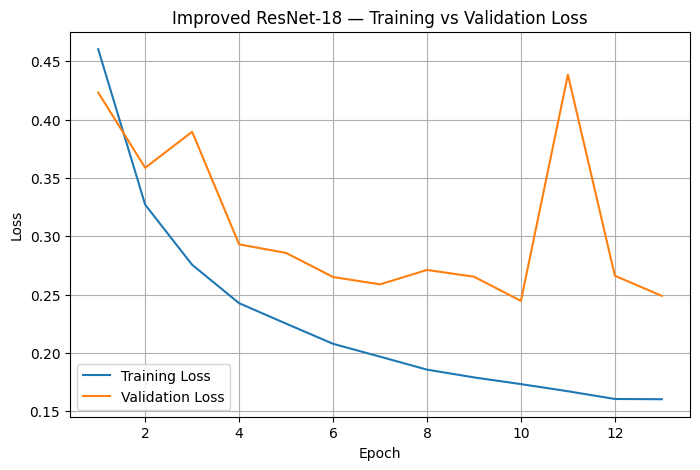

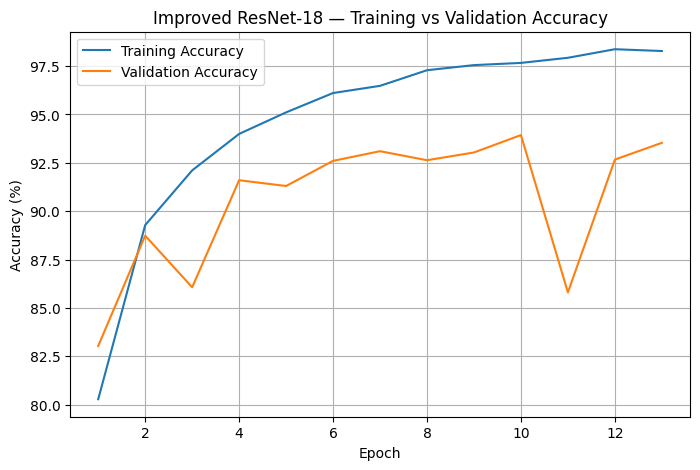

In [ ]:
import matplotlib.pyplot as plt

epochs_done = range(1, len(train_losses) + 1)

# Loss curve
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_done,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_done,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved ResNet-18 — Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# Accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_done,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs_done,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Improved ResNet-18 — Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 17: FINAL TEST EVALUATION


This cell evaluates the trained ResNet-18 model on the held-out test dataset.
It loads the best-performing model checkpoint before evaluation.
Predictions and true labels are collected for all test images.
Accuracy, precision, recall, F1-score, and the confusion matrix are calculated.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load BEST model
model.load_state_dict(
    torch.load(
        "/content/best_resnet18_improved.pth",
        map_location=device
    )
)

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())


# Metrics
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("=" * 70)
print("IMPROVED RESNET-18 — FINAL TEST RESULTS")
print("=" * 70)

print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Precision     : {precision * 100:.2f}%")
print(f"Recall        : {recall * 100:.2f}%")
print(f"F1 Score      : {f1 * 100:.2f}%")

print()
print("Confusion Matrix:")
print(cm)

print()
print("Classification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["REAL", "FAKE"],
        digits=4
    )
)

print("=" * 70)

IMPROVED RESNET-18 — FINAL TEST RESULTS
Test Accuracy : 94.10%
Precision     : 95.53%
Recall        : 92.53%
F1 Score      : 94.01%

Confusion Matrix:
[[1435   65]
 [ 112 1388]]

Classification Report:
              precision    recall  f1-score   support

        REAL     0.9276    0.9567    0.9419      1500
        FAKE     0.9553    0.9253    0.9401      1500

    accuracy                         0.9410      3000
   macro avg     0.9414    0.9410    0.9410      3000
weighted avg     0.9414    0.9410    0.9410      3000



# 18: CONFUSION MATRIX

This cell evaluates the trained ResNet-18 model on the held-out test dataset.
It loads the best-performing model checkpoint before evaluation.
Predictions and true labels are collected for all test images.
Accuracy, precision, recall, F1-score, and the confusion matrix are calculated.

Confusion Matrix:
[[1435   65]
 [ 112 1388]]


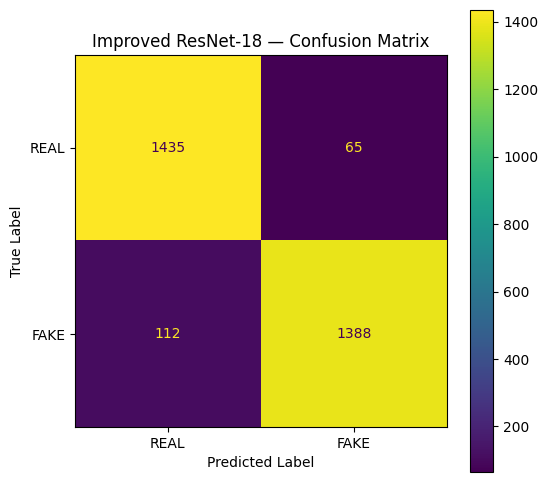

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["REAL", "FAKE"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")

plt.title("Improved ResNet-18 — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

#19: ROC CURVE + AUC

This cell evaluates the model’s ability to distinguish REAL and FAKE images across different decision thresholds.
It collects the true labels and prediction probabilities from the test dataset.
The ROC curve is generated using the false-positive and true-positive rates.
ROC-AUC is calculated to measure the model’s overall classification performance.

RESNET-18 — ROC ANALYSIS
ROC-AUC : 0.9851


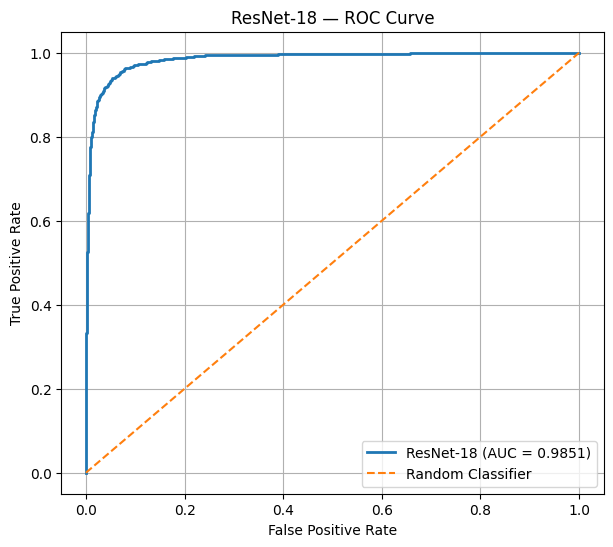

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

model.eval()

all_test_labels = []
all_test_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        # Probability of FAKE class (class 1)
        probabilities = torch.softmax(outputs, dim=1)

        fake_probabilities = probabilities[:, 1]

        all_test_probs.extend(
            fake_probabilities.cpu().numpy()
        )

        all_test_labels.extend(
            labels.numpy()
        )

# Convert to numpy
all_test_labels = np.array(all_test_labels)
all_test_probs = np.array(all_test_probs)

# ROC
fpr, tpr, thresholds = roc_curve(
    all_test_labels,
    all_test_probs
)

auc_score = roc_auc_score(
    all_test_labels,
    all_test_probs
)

print("=" * 70)
print("RESNET-18 — ROC ANALYSIS")
print("=" * 70)

print(f"ROC-AUC : {auc_score:.4f}")
print("=" * 70)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ResNet-18 (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet-18 — ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

This project presents a deep-learning based image-forensics system for identifying whether an image is REAL or AI-generated (FAKE).
The study begins by inspecting a large collection of GAN-based datasets and identifying different generation categories such as StyleGAN2, StyleGAN3, ProGAN, BigGAN, CycleGAN, Projected GAN, Diffusion GAN, GANformer, and GauGAN.
The ProGAN dataset was selected for the initial experiment because its directory structure clearly separates REAL and FAKE images.
A balanced dataset containing 20,000 images was created, with 10,000 REAL images and 10,000 FAKE images.
The dataset was divided into training, validation, and test sets while maintaining a balanced class distribution.

For image preprocessing, all images were resized to 224 × 224 pixels and converted into RGB tensors.
Data augmentation techniques such as random horizontal flipping and random rotation were applied to the training images.
A pretrained ResNet-18 architecture was used as the main image-forensics model and adapted for two-class classification.
The model was trained using AdamW with a learning rate of 0.0001 and weight decay for regularization.
CrossEntropyLoss with 0.05 label smoothing was used to reduce overconfident predictions.
ReduceLROnPlateau was used to automatically reduce the learning rate when validation loss stopped improving, while early stopping helped prevent unnecessary training.

The improved ResNet-18 achieved a best validation accuracy of 93.93% during training.
On the ProGAN test set, the model achieved 94.10% accuracy, 95.53% precision, 92.53% recall, and 94.01% F1-score.
The ROC-AUC score of 0.9837 indicates strong discrimination between REAL and FAKE images within the ProGAN test distribution.
The confusion matrix was also analyzed to understand the number of correctly and incorrectly classified REAL and FAKE samples.
Training and validation loss and accuracy curves were plotted to examine the learning behavior and identify possible overfitting.

To evaluate real-world generalization, the trained model was tested on the independent CIFAKE dataset without additional training or fine-tuning.
The performance dropped substantially to approximately 52.94% accuracy, with a ROC-AUC of 0.5654.
This large performance difference demonstrates that a model trained primarily on one GAN source may learn dataset-specific characteristics rather than general AI-generated image artifacts.

To improve generalization, a mixed-source forensic dataset was created using both ProGAN and CIFAKE images.
The resulting dataset contains 28,000 images, consisting of 14,000 REAL and 14,000 FAKE images.
This generalized dataset was divided into training, validation, and internal test sets while keeping both classes balanced.
The next stage of the project focuses on training ResNet-18 on this mixed-source dataset and evaluating whether exposure to multiple image-generation sources improves cross-dataset forensic detection.

Overall, the project demonstrates that high accuracy on a single dataset is not sufficient to establish a robust AI-image detector.
Cross-dataset testing is essential for measuring generalization, and mixed-source training provides a practical approach toward building a more reliable and generalized image-forensics system.